In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ibrl.environments import NewcombEnvironment,AsymmetricDeathInDamascusEnvironment
from ibrl.agents import InfraBayesianAgent
from ibrl.infrabayesian import WorldModel,AMeasure,Infradistribution,NewcombWorldModel
from ibrl.utils import sample_action
from ibrl.simulators import simulate

In [2]:
def simulate_environment(env, x, steps=1000):
    wm = NewcombWorldModel(env.reward_table)  # WM needs to know reward matrix
    m = AMeasure(wm.make_params(1))
    dist = Infradistribution([m],wm)
    agent = InfraBayesianAgent(
        num_actions=2,
        epsilon=0.,
        hypotheses=[dist],
        reward_function=wm.agent_reward_matrix(),
        policy_discretisation=5)

    optimal = []
    simulated = []
    action_rate = []
    for i,p in enumerate(x):
        env.predictor_accuracy = m.params.predictor_accuracy = p
        results = simulate(env, agent, {"num_steps": steps})
        optimal.append(results["optimal_reward"])
        simulated.append(results["average_reward"][0].mean())
        action_rate.append(results["probabilities"][0][:,1].mean())
    return optimal,simulated,action_rate

In [3]:
x = np.linspace(0.5, 1.0, 51)
optimal1,simulated1,rate1 = simulate_environment(NewcombEnvironment(2, boxA=1,boxB=10), x, 4000)

/tmp/ipykernel_103330/3174242805.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8)


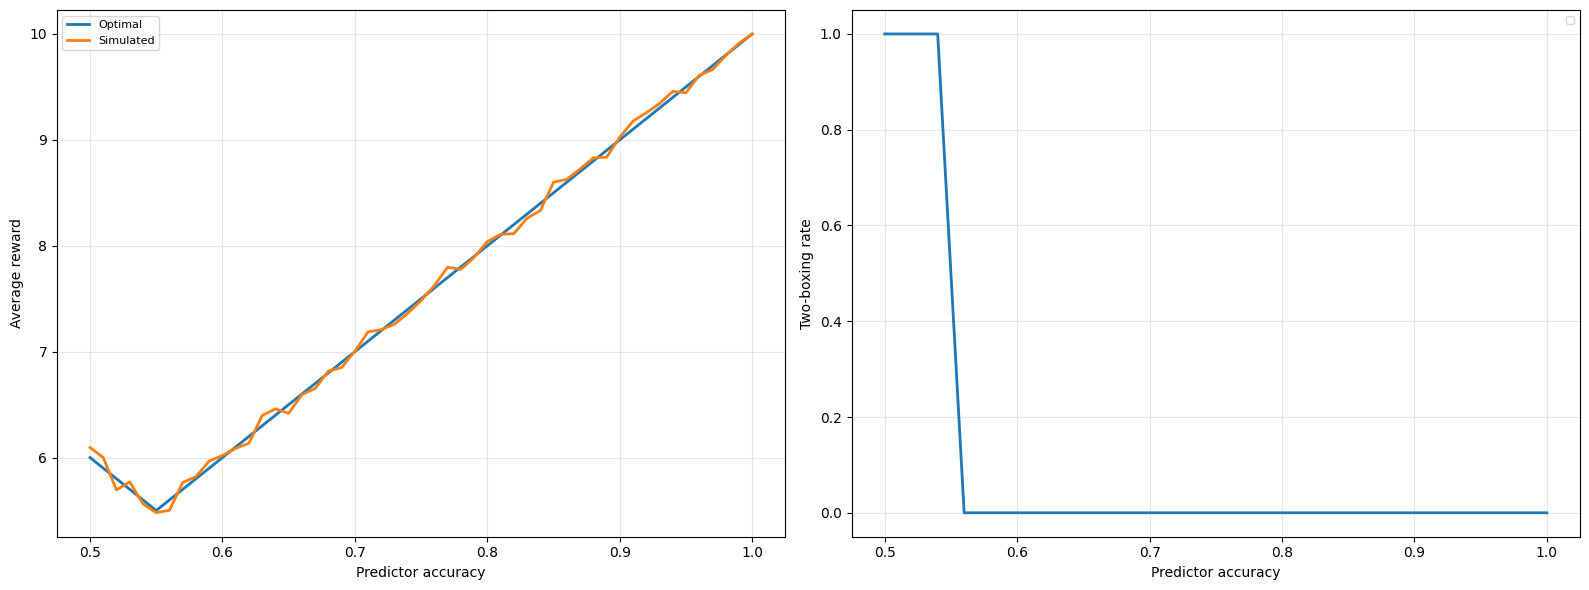

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
ax.plot(x,optimal1, linewidth=2, label="Optimal")
ax.plot(x,simulated1, linewidth=2, label="Simulated")
ax.set_xlabel("Predictor accuracy")
ax.set_ylabel("Average reward")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(x,rate1, linewidth=2)
ax.set_xlabel("Predictor accuracy")
ax.set_ylabel("Two-boxing rate")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [5]:
x = np.linspace(0.5, 1.0, 51)
optimal2,simulated2,rate2 = simulate_environment(AsymmetricDeathInDamascusEnvironment(2), x, 4000)

/tmp/ipykernel_103330/4215075467.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8)


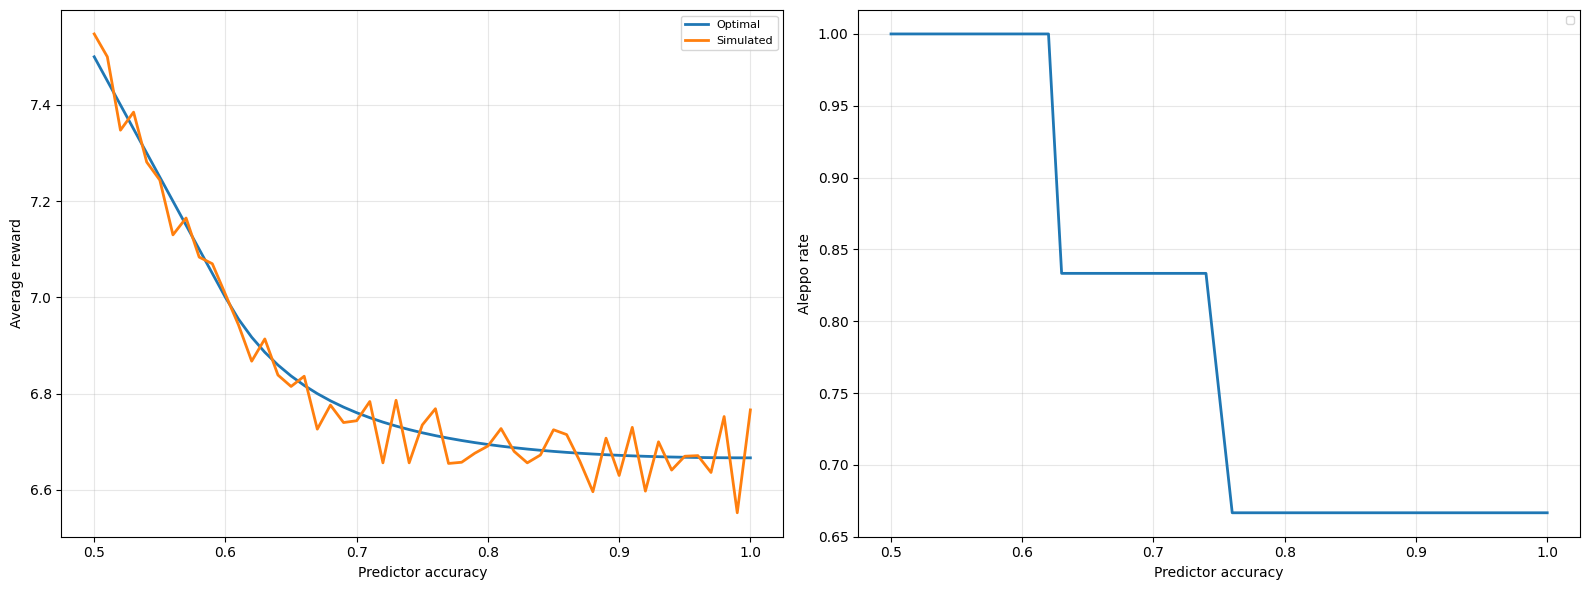

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
ax.plot(x,optimal2, linewidth=2, label="Optimal")
ax.plot(x,simulated2, linewidth=2, label="Simulated")
ax.set_xlabel("Predictor accuracy")
ax.set_ylabel("Average reward")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(x,rate2, linewidth=2)
ax.set_xlabel("Predictor accuracy")
ax.set_ylabel("Aleppo rate")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()